# Phase 3B: prospective matched-contrast validation

This notebook executes `phase3a_protocol_version: 1.1` unchanged. Event anchors are metric-independent sampling mechanisms, not tactical labels. Sample construction and context balance are shown before relational outcomes. Typed families remain separate.

In [1]:
from pathlib import Path
import json, hashlib, itertools, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
cfg=json.loads((ROOT/'config'/'phase3a_validation_protocol.json').read_text())
assert cfg['phase3a_protocol_version']=='1.1' and cfg['random_seed']==20260828
L,W=cfg['coordinate_system']['pitch_length_m'],cfg['coordinate_system']['pitch_width_m']
TOL=cfg['coordinate_system']['numeric_zero_tolerance']; BASE=cfg['random_seed']
DATA=ROOT/'data'/'metrica_sample_game_1'
def load_tracking(path,team):
    h=pd.read_csv(path,header=None,nrows=3)
    ids=[str(int(float(v))) for v in h.iloc[1,3:-2:2] if pd.notna(v)]
    cols=['Period','Frame','Time [s]']
    for p in ids: cols += [f'{team}_{p}_x',f'{team}_{p}_y']
    cols += [f'{team}_ball_x',f'{team}_ball_y']
    return pd.read_csv(path,skiprows=3,names=cols),ids
home,hp=load_tracking(DATA/'Sample_Game_1_RawTrackingData_Home_Team.csv','Home')
away,ap=load_tracking(DATA/'Sample_Game_1_RawTrackingData_Away_Team.csv','Away')
events=pd.read_csv(DATA/'Sample_Game_1_RawEventsData.csv')
tracking=home.merge(away.drop(columns=['Period','Time [s]']),on='Frame',validate='one_to_one')
tracking=tracking.reset_index(drop=True)
time_index={(int(r.Period),round(float(r['Time [s]']),2)):i for i,r in tracking[['Period','Time [s]']].iterrows()}
players={'Home':hp,'Away':ap}; goalkeeper={'Home':'11','Away':'25'}
def outfield(team): return [p for p in players[team] if p!=goalkeeper[team]]
def other(team): return 'Away' if team=='Home' else 'Home'
def xy(r,team,p): return np.array([r[f'{team}_{p}_x']*L,r[f'{team}_{p}_y']*W],float)
def ball(r): return np.array([r.Home_ball_x*L,r.Home_ball_y*W],float)
print({'protocol':cfg['phase3a_protocol_version'],'tracking':tracking.shape,'events':events.shape})

{'protocol': '1.1', 'tracking': (145006, 63), 'events': (1745, 14)}


In [2]:
RESTART_TYPES=set(cfg['restarts']['event_type_any']); RESTART_SUB=set(cfg['restarts']['event_subtype_any']); PB=set(cfg['possession']['possession_bearing_event_types'])
restart_times={p:sorted(events.loc[(events.Period==p)&(events.Type.isin(RESTART_TYPES)|events.Subtype.isin(RESTART_SUB)),'Start Time [s]'].dropna()) for p in [1,2]}
reception_times={p:sorted(events.loc[(events.Period==p)&events.Type.eq('PASS')&events.To.notna(),'End Time [s]'].dropna()) for p in [1,2]}
poss_events=events[events.Type.isin(PB)&events.Team.notna()&events['Start Time [s]'].notna()].sort_values(['Period','Start Time [s]'])
def possession_at(period,t):
    z=poss_events[(poss_events.Period==period)&(poss_events['Start Time [s]']<=t)]
    return None if z.empty else z.iloc[-1].Team
def near_any(t,vals,d=5.): return any(abs(t-x)<d-1e-12 for x in vals)
def overlaps(a,b): return a[0] < b[1]-1e-12 and b[0] < a[1]-1e-12
def row_at(period,t):
    i=time_index.get((int(period),round(float(t),2)))
    return None if i is None else tracking.iloc[i]
def window_at(period,t,bounds):
    lo,hi=t+bounds[0],t+bounds[1]
    expected=int(round((bounds[1]-bounds[0])*25))+1
    i=time_index.get((int(period),round(float(lo),2)))
    if i is None:return None
    z=tracking.iloc[i:i+expected].copy()
    if len(z)!=expected or z.Period.nunique()!=1 or int(z.Period.iloc[0])!=period or abs(z['Time [s]'].iloc[-1]-hi)>1e-6:return None
    return z
def zone(r):
    b=np.array([r.Home_ball_x,r.Home_ball_y],float)
    return None if not np.isfinite(b).all() else f'{min(int(b[0]*3),2)}-{min(int(b[1]*3),2)}'
def bin3(v,e1,e2): return None if not np.isfinite(v) else (0 if v<e1 else 1 if v<=e2 else 2)
def pre_bins(period,t,poss):
    a,b=row_at(period,t),row_at(period,t-1)
    if a is None or b is None:return None,None
    bd=np.linalg.norm(ball(a)-ball(b)) if np.isfinite(ball(a)).all() and np.isfinite(ball(b)).all() else np.nan
    dt=other(poss); ids=[p for p in outfield(dt) if np.isfinite(xy(a,dt,p)).all() and np.isfinite(xy(b,dt,p)).all()]
    cd=np.linalg.norm(np.mean([xy(a,dt,p) for p in ids],0)-np.mean([xy(b,dt,p) for p in ids],0)) if ids else np.nan
    return bin3(bd,2,5),bin3(cd,1,2.5)
def anchor_record(period,t,poss,bounds,source,event_id=None):
    r=row_at(period,t); w=window_at(period,t,bounds)
    if r is None:return None,'missing_anchor_frame'
    if w is None:return None,'boundary_or_incomplete_window'
    b=ball(r)
    if not np.isfinite(b).all():return None,'missing_anchor_ball'
    dt=other(poss); valid=[p for p in outfield(dt) if np.isfinite(xy(r,dt,p)).all()]
    if len(valid)<3:return None,'insufficient_defenders'
    focal=min(valid,key=lambda p:(np.linalg.norm(xy(r,dt,p)-b),int(p)))
    start=w.iloc[0]; mates=[p for p in valid if p!=focal and np.isfinite(xy(start,dt,p)).all()]
    if len(mates)<2:return None,'insufficient_local'
    mates=sorted(mates,key=lambda p:(np.linalg.norm(xy(start,dt,p)-xy(start,dt,focal)),int(p)))[:2]
    opp=[p for p in outfield(poss) if np.isfinite(xy(start,poss,p)).all()]
    if len(opp)<2:return None,'insufficient_opponents'
    opp=sorted(opp,key=lambda p:(np.linalg.norm(xy(start,poss,p)-xy(start,dt,focal)),int(p)))[:2]
    required=[f'{dt}_{p}_{a}' for p in valid for a in ('x','y')]+[f'{poss}_{p}_{a}' for p in opp for a in ('x','y')]
    if w[required].isna().any().any():return None,'core_coordinate_incomplete'
    pb,pc=pre_bins(period,t,poss)
    rec={'period':int(period),'time':float(t),'possession':poss,'def_team':dt,'focal':focal,'n1':mates[0],'n2':mates[1],'o1':opp[0],'o2':opp[1],'available_defenders':len(valid),'zone':zone(r),'window':w,'source':source,'event_id':event_id,'pre_ball_bin':pb,'pre_centroid_bin':pc}
    return rec,None
def suppress(records,bounds):
    keep=[]; n=0
    for r in sorted(records,key=lambda x:(x['period'],x['time'])):
        iv=(r['time']+bounds[0],r['time']+bounds[1])
        if keep and keep[-1]['period']==r['period'] and overlaps(iv,(keep[-1]['time']+bounds[0],keep[-1]['time']+bounds[1])):n+=1
        else:keep.append(r)
    return keep,n
def reception_candidates(bounds):
    raw=events[events.Type.eq('PASS')]; counts={'total_passes':len(raw)}; eligible=[]
    for idx,e in raw.iterrows():
        if pd.isna(e.To):counts['missing_To']=counts.get('missing_To',0)+1;continue
        if pd.isna(e['End Time [s]']) or pd.isna(e['End Frame']):counts['missing_end_anchor']=counts.get('missing_end_anchor',0)+1;continue
        p=int(e.Period);t=float(e['End Time [s]'])
        if near_any(t,restart_times[p]):counts['restart_proximity']=counts.get('restart_proximity',0)+1;continue
        rec,why=anchor_record(p,t,e.Team,bounds,'reception',idx)
        if rec is None:counts[why]=counts.get(why,0)+1
        else:eligible.append(rec)
    counts['eligible_before_overlap']=len(eligible);keep,n=suppress(eligible,bounds);counts['overlap_suppressed']=n;counts['retained']=len(keep)
    return keep,counts,eligible
def possession_change_candidates(bounds):
    prev={1:None,2:None}; eligible=[]; counts={'qualifying_possession_events':len(poss_events),'team_changes':0}
    for idx,e in poss_events.iterrows():
        p=int(e.Period);team=e.Team
        if prev[p] is not None and team!=prev[p]:
            counts['team_changes']+=1;t=float(e['Start Time [s]'])
            if near_any(t,restart_times[p]):counts['restart_proximity']=counts.get('restart_proximity',0)+1
            else:
                rec,why=anchor_record(p,t,team,bounds,'possession_change',idx)
                if rec is None:counts[why]=counts.get(why,0)+1
                else:eligible.append(rec)
        prev[p]=team
    counts['eligible_before_overlap']=len(eligible);keep,n=suppress(eligible,bounds);counts['overlap_suppressed']=n;counts['retained']=len(keep)
    return keep,counts,eligible
def control_pool(candidates,bounds,eligible_receptions):
    pool=[]; reasons={}; civ={p:[(c['time']+bounds[0],c['time']+bounds[1]) for c in candidates if c['period']==p] for p in [1,2]}
    ert={p:[c['time'] for c in eligible_receptions if c['period']==p] for p in [1,2]}
    for p in [1,2]:
        ts=tracking.loc[tracking.Period==p,'Time [s]'];lo,hi=math.ceil(ts.min()),math.floor(ts.max())
        for t in range(lo,hi+1):
            if near_any(t,ert[p]):reasons['reception_distance']=reasons.get('reception_distance',0)+1;continue
            if near_any(t,restart_times[p]):reasons['restart_distance']=reasons.get('restart_distance',0)+1;continue
            if any(overlaps((t+bounds[0],t+bounds[1]),iv) for iv in civ[p]):reasons['candidate_overlap']=reasons.get('candidate_overlap',0)+1;continue
            poss=possession_at(p,t)
            if poss is None:reasons['missing_possession']=reasons.get('missing_possession',0)+1;continue
            rec,why=anchor_record(p,float(t),poss,bounds,'control')
            if rec is None:reasons[why]=reasons.get(why,0)+1
            else:pool.append(rec)
    return pool,reasons
def match_records(candidates,pool,bounds,extra=False):
    available=list(pool);pairs=[];unmatched=[]
    for c in sorted(candidates,key=lambda x:(x['period'],x['time'])):
        options=[]
        for q in available:
            ok=q['period']==c['period'] and q['possession']==c['possession'] and q['zone']==c['zone'] and q['available_defenders']==c['available_defenders'] and abs(q['time']-c['time'])<=300
            if extra:ok=ok and q['pre_ball_bin']==c['pre_ball_bin'] and q['pre_centroid_bin']==c['pre_centroid_bin']
            if ok:options.append(q)
        if not options:unmatched.append(c);continue
        q=min(options,key=lambda x:(abs(x['time']-c['time']),x['time']));pairs.append((c,q));iv=(q['time']+bounds[0],q['time']+bounds[1])
        available=[x for x in available if not (x['period']==q['period'] and overlaps((x['time']+bounds[0],x['time']+bounds[1]),iv))]
    return pairs,unmatched


In [3]:
FAMILIES=cfg['descriptor_families']
def pathlen(a): return np.nansum(np.linalg.norm(np.diff(a,axis=0),axis=1))
def triangle_area(a,b,c):
    u,v=b-a,c-a
    return abs(u[0]*v[1]-u[1]*v[0])/2
def descriptors(r):
    w=r['window']; dt=r['def_team']; f,n1,n2=r['focal'],r['n1'],r['n2']; poss=r['possession']; o1,o2=r['o1'],r['o2']
    D={p:np.c_[w[f'{dt}_{p}_x']*L,w[f'{dt}_{p}_y']*W] for p in outfield(dt) if f'{dt}_{p}_x' in w and w[[f'{dt}_{p}_x',f'{dt}_{p}_y']].notna().all().all()}
    P={p:np.c_[w[f'{poss}_{p}_x']*L,w[f'{poss}_{p}_y']*W] for p in (o1,o2)}
    ids=list(D); C=np.mean(np.stack([D[p] for p in ids]),axis=0)
    loo=np.mean(np.stack([D[p] for p in ids if p!=f]),axis=0)
    local=np.stack([D[f],D[n1],D[n2]])
    lc=local.mean(axis=0); rel=local-lc[None,:,:]
    disp=np.stack([D[p][-1]-D[p][0] for p in ids]); norms=np.linalg.norm(disp,axis=1)
    moving=norms>TOL
    coh=np.linalg.norm((disp[moving]/norms[moving,None]).mean(axis=0)) if moving.any() else np.nan
    xspan=np.ptp(local[:,:,0],axis=0); yspan=np.ptp(local[:,:,1],axis=0)
    area=np.array([triangle_area(*local[:,i,:]) for i in range(len(w))])
    def rev(axis):
        for a,b in ((0,1),(0,2),(1,2)):
            s=local[a,0,axis]-local[b,0,axis];e=local[a,-1,axis]-local[b,-1,axis]
            if abs(s)>TOL and abs(e)>TOL and s*e<0:return 1.
        return 0.
    out={'centroid_x_displacement':C[-1,0]-C[0,0],'centroid_y_displacement':C[-1,1]-C[0,1],
         'centroid_path_length':pathlen(C),'directional_coherence':coh,
         'loo_relative_x_change':(D[f][-1]-loo[-1])[0]-(D[f][0]-loo[0])[0],
         'loo_relative_y_change':(D[f][-1]-loo[-1])[1]-(D[f][0]-loo[0])[1],
         'loo_relative_path_length':pathlen(D[f]-loo),
         'focal_neighbor_1_distance_change':np.linalg.norm(D[f][-1]-D[n1][-1])-np.linalg.norm(D[f][0]-D[n1][0]),
         'focal_neighbor_2_distance_change':np.linalg.norm(D[f][-1]-D[n2][-1])-np.linalg.norm(D[f][0]-D[n2][0]),
         'neighbor_1_neighbor_2_distance_change':np.linalg.norm(D[n1][-1]-D[n2][-1])-np.linalg.norm(D[n1][0]-D[n2][0]),
         'x_span_change':xspan[-1]-xspan[0],'y_span_change':yspan[-1]-yspan[0],'area_change':area[-1]-area[0],
         'x_order_reversal':rev(0),'y_order_reversal':rev(1)}
    for i,p in enumerate((f,n1,n2)):
        name=('focal','neighbor_1','neighbor_2')[i]
        out[f'{name}_relative_x_change']=rel[i,-1,0]-rel[i,0,0];out[f'{name}_relative_y_change']=rel[i,-1,1]-rel[i,0,1]
    for j,p in enumerate((o1,o2),1):
        v=P[p]-D[f]
        out[f'opponent_{j}_relative_x_change']=v[-1,0]-v[0,0];out[f'opponent_{j}_relative_y_change']=v[-1,1]-v[0,1]
        out[f'opponent_{j}_distance_change']=np.linalg.norm(v[-1])-np.linalg.norm(v[0])
    B=np.c_[w.Home_ball_x*L,w.Home_ball_y*W]
    if np.isfinite(B).all():
        out['ball_displacement']=np.linalg.norm(B[-1]-B[0]); fb=D[f]-B
        out['focal_ball_x_change']=fb[-1,0]-fb[0,0];out['focal_ball_y_change']=fb[-1,1]-fb[0,1]
    else:
        out.update(ball_displacement=np.nan,focal_ball_x_change=np.nan,focal_ball_y_change=np.nan)
    out['sum_defending_outfield_player_path_lengths']=sum(pathlen(D[p]) for p in ids)
    return out

def child_seed(name): return int(hashlib.sha256(f'{BASE}:{name}'.encode()).hexdigest()[:8],16)
def sign_p(d,name):
    d=np.asarray(d,float);d=d[np.isfinite(d)&(np.abs(d)>TOL)];n=len(d);obs=abs(d.sum())
    if not n:return np.nan,'none'
    if n<=20:
        vals=np.array([abs(np.dot(s,d)) for s in itertools.product([-1,1],repeat=n)])
        return np.mean(vals>=obs-1e-12),'exact'
    rng=np.random.default_rng(child_seed(name)); vals=np.abs((rng.choice([-1,1],size=(100000,n))*d).sum(axis=1))
    return (np.sum(vals>=obs-1e-12)+1)/100001,'monte_carlo'
def binom_p(a,b):
    n=a+b
    if not n:return 1.
    k=min(a,b); return min(1.,2*sum(math.comb(n,i) for i in range(k+1))/2**n)
def holm(ps):
    ps=np.asarray(ps,float);out=np.full(len(ps),np.nan);ok=np.where(np.isfinite(ps))[0];order=ok[np.argsort(ps[ok])];run=0
    for rank,i in enumerate(order): run=max(run,(len(order)-rank)*ps[i]);out[i]=min(1,run)
    return out
def analyse(pairs,label):
    rows=[]
    for i,(c,q) in enumerate(pairs):
        cd,qd=descriptors(c),descriptors(q)
        for fam,names in FAMILIES.items():
            for name in names: rows.append({'pair':i,'family':fam,'descriptor':name,'candidate':cd[name],'control':qd[name]})
    raw=pd.DataFrame(rows); summary=[]
    for (fam,name),g in raw.groupby(['family','descriptor'],sort=False):
        z=g.dropna(); d=(z.candidate-z.control).to_numpy();
        if name.endswith('_reversal'):
            b=int(((z.candidate==1)&(z.control==0)).sum());a=int(((z.candidate==0)&(z.control==1)).sum());p=binom_p(a,b);method='exact McNemar/binomial'
        else:p,method=sign_p(d,f'{label}:{fam}:{name}')
        rng=np.random.default_rng(child_seed(f'boot:{label}:{fam}:{name}'))
        boots=np.array([np.median(rng.choice(d,size=len(d),replace=True)) for _ in range(10000)]) if len(d) else np.array([np.nan])
        summary.append({'family':fam,'descriptor':name,'n':len(d),'candidate_median':np.median(z.candidate),'control_median':np.median(z.control),'median_difference':np.median(d),'ci_low':np.nanpercentile(boots,2.5),'ci_high':np.nanpercentile(boots,97.5),'dz':np.mean(d)/np.std(d,ddof=1) if len(d)>1 and np.std(d,ddof=1)>TOL else np.nan,'p':p,'test':method})
    s=pd.DataFrame(summary);s['p_holm']=s.groupby('family',group_keys=False).p.transform(lambda x:holm(x.to_numpy()))
    return raw,s


In [4]:
BOUNDS=(-2,3)
candidates,attrition,eligible=reception_candidates(BOUNDS)
pool,pool_attrition=control_pool(candidates,BOUNDS,eligible)
pairs,unmatched=match_records(candidates,pool,BOUNDS)
support=len(pairs)/len(candidates) if candidates else 0
print('Primary attrition');display(pd.Series(attrition,name='count').to_frame())
required_support=cfg['matching']['support_failure']['minimum_matched_fraction']
print({'control_pool':len(pool),'matched_pairs':len(pairs),'unmatched_candidates':len(unmatched),'matching_support':support,'required_support':required_support})
if support<required_support: print('Frozen design is poorly supported; rules are not loosened.')
context=pd.DataFrame([{'period':c['period'],'possession':c['possession'],'zone':c['zone'],'defenders':c['available_defenders'],'candidate_time':c['time'],'control_time':q['time'],'time_difference':q['time']-c['time']} for c,q in pairs])
display(context.groupby(['period','possession','zone','defenders']).size().rename('pairs').reset_index())
display(context[['candidate_time','control_time','time_difference']].describe())

Primary attrition


,count
total_passes,799
restart_proximity,182
eligible_before_overlap,617
overlap_suppressed,302
retained,315


{'control_pool': 429, 'matched_pairs': 46, 'unmatched_candidates': 269, 'matching_support': 0.14603174603174604, 'required_support': 0.7}
Frozen design is poorly supported; rules are not loosened.


,period,possession,zone,defenders,pairs
0,1,Away,1-0,10,1
1,1,Away,1-1,10,1
2,1,Away,1-2,10,7
3,1,Away,2-1,10,1
4,1,Home,0-1,10,3
5,1,Home,1-1,10,2
6,1,Home,2-1,10,3
7,2,Away,0-1,10,3
8,2,Away,1-1,10,3
9,2,Away,1-2,10,1


,candidate_time,control_time,time_difference
count,46.000000,46.000000,46.000000
mean,3311.543478,3382.565217,71.021739
std,1856.808835,1818.622454,172.871535
min,91.560000,238.000000,-282.600000
25%,1468.830000,1573.500000,-87.030000
50%,3732.480000,3938.000000,105.140000
75%,4978.510000,4967.750000,239.360000
max,5725.480000,5720.000000,299.640000


FAMILY: collective


,family,descriptor,n,candidate_median,control_median,median_difference,ci_low,ci_high,dz,p,test,p_holm
0,collective,centroid_x_displacement,46,-0.826718,-1.820805,1.157310,-5.395005,4.320435,-0.043955,0.766822,monte_carlo,1.00000
1,collective,centroid_y_displacement,46,0.661470,0.479400,-0.037298,-2.762024,2.748968,0.020007,0.892351,monte_carlo,1.00000
2,collective,centroid_path_length,46,11.044029,7.548852,3.923678,1.122620,4.762390,0.542564,0.000460,monte_carlo,0.00184
3,collective,directional_coherence,46,0.873397,0.862013,-0.005775,-0.024896,0.067152,0.040222,0.787232,monte_carlo,1.00000


FAMILY: focal


,family,descriptor,n,candidate_median,control_median,median_difference,ci_low,ci_high,dz,p,test,p_holm
0,focal,loo_relative_x_change,46,0.813575,0.494783,-1.188425,-3.504317,2.063367,-0.139162,0.348627,monte_carlo,0.697253
1,focal,loo_relative_y_change,46,-0.320544,-0.516007,0.408189,-2.527711,2.859324,0.089081,0.549205,monte_carlo,0.697253
2,focal,loo_relative_path_length,46,10.449537,5.074070,5.012211,1.459563,7.709771,0.567794,0.000280,monte_carlo,0.000840


FAMILY: local_configuration


...

FAMILY: ball_context


,family,descriptor,n,candidate_median,control_median,median_difference,ci_low,ci_high,dz,p,test,p_holm
0,ball_context,ball_displacement,20,27.586304,9.064023,14.722912,1.441654,21.969744,0.564521,0.021759,exact,0.065277
1,ball_context,focal_ball_x_change,20,3.457125,-0.381150,1.386000,-6.271125,13.296675,0.106344,0.637281,exact,1.000000
2,ball_context,focal_ball_y_change,20,-10.878980,0.034340,-4.364580,-17.155720,11.453240,0.006781,0.975956,exact,1.000000


FAMILY: generic_activity


,family,descriptor,n,candidate_median,control_median,median_difference,ci_low,ci_high,dz,p,test,p_holm
0,generic_activity,sum_defending_outfield_player_path_lengths,46,126.451843,89.380388,33.963516,23.210516,56.038586,0.714873,0.00001,monte_carlo,0.00001


/Users/jeremy/Projects/soccer-defensive-adjustment/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1810: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


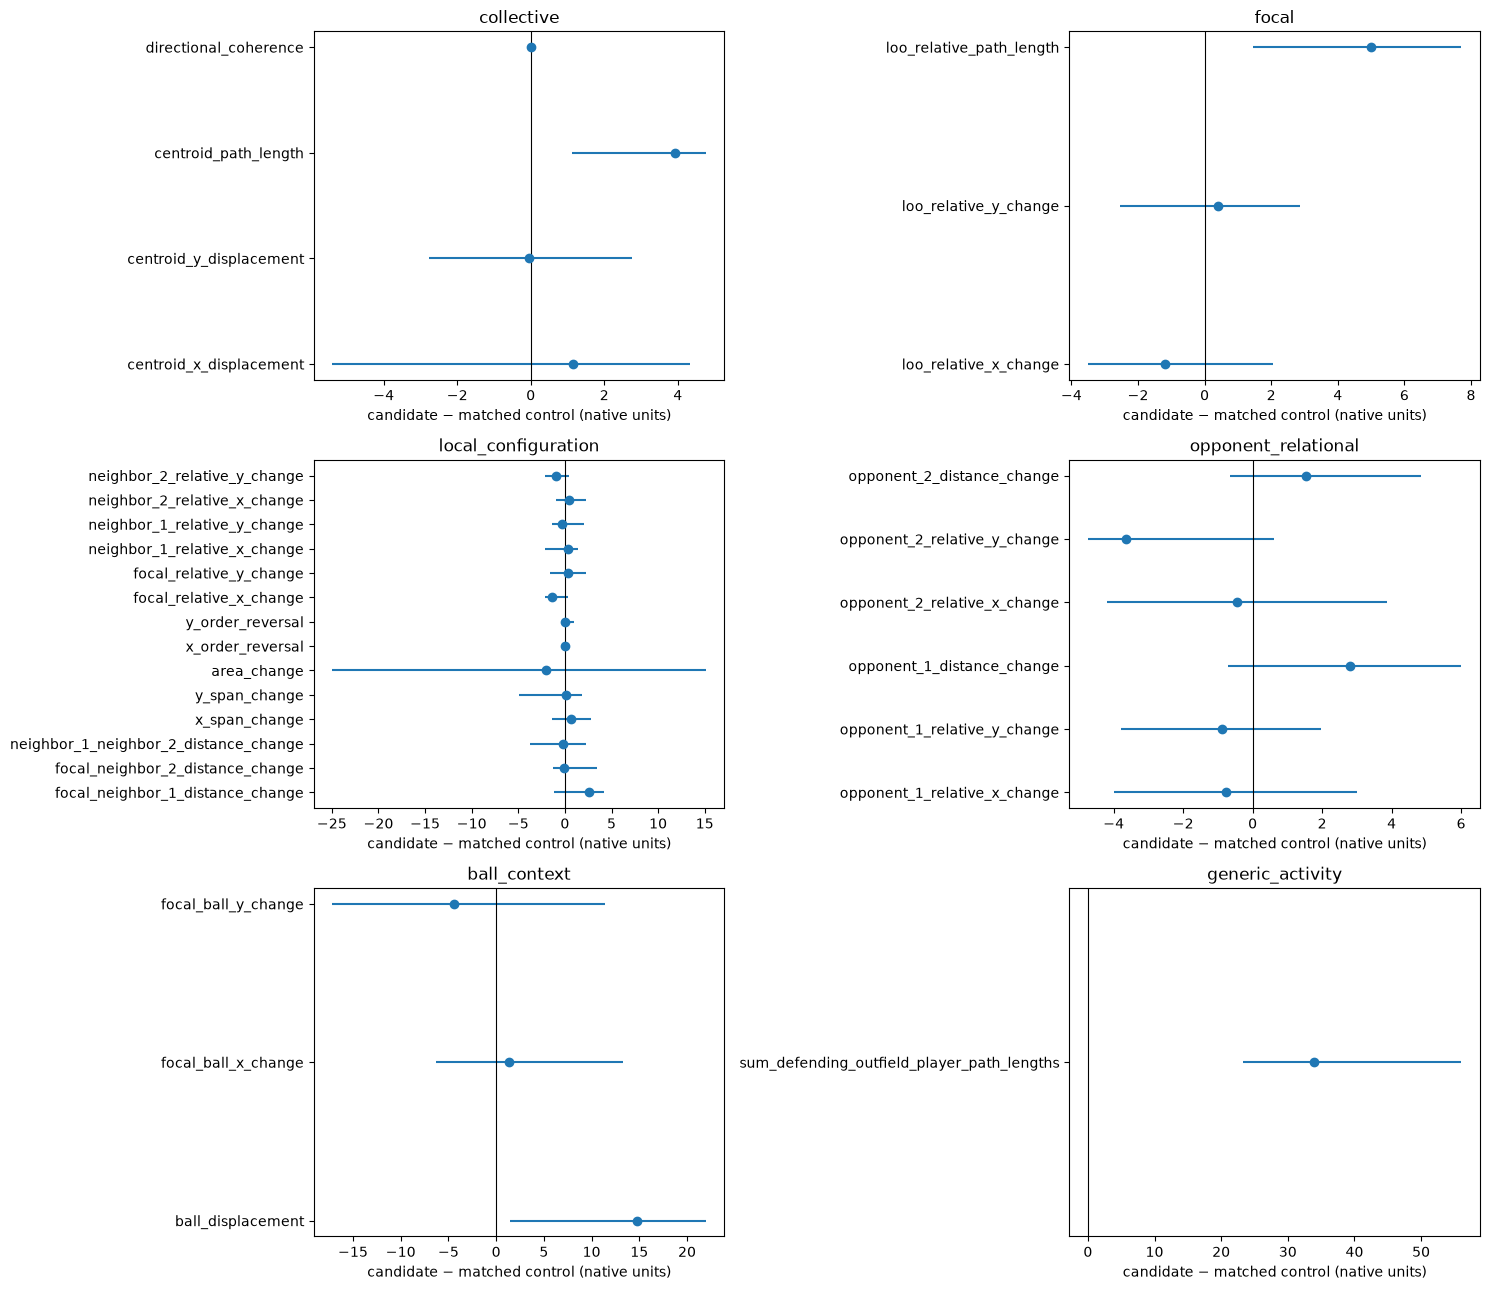

/var/folders/zk/r02nt9yn42130fswlkzl_whm0000gn/T/ipykernel_23997/227705307.py:11: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  g.boxplot(column=['candidate','control'],by='descriptor',ax=axs[0],rot=90);axs[0].set_title(f'{fam}: raw');axs[0].set_ylabel('native units')


Raw paired distributions (not selected by result):


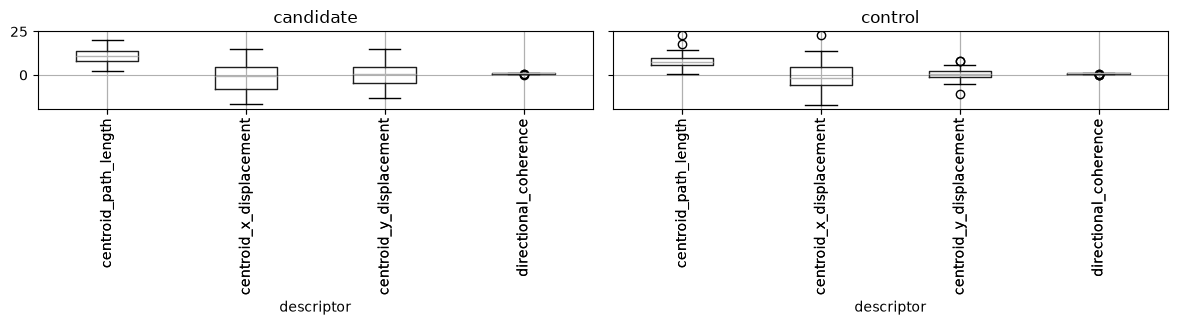

/var/folders/zk/r02nt9yn42130fswlkzl_whm0000gn/T/ipykernel_23997/227705307.py:11: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  g.boxplot(column=['candidate','control'],by='descriptor',ax=axs[0],rot=90);axs[0].set_title(f'{fam}: raw');axs[0].set_ylabel('native units')


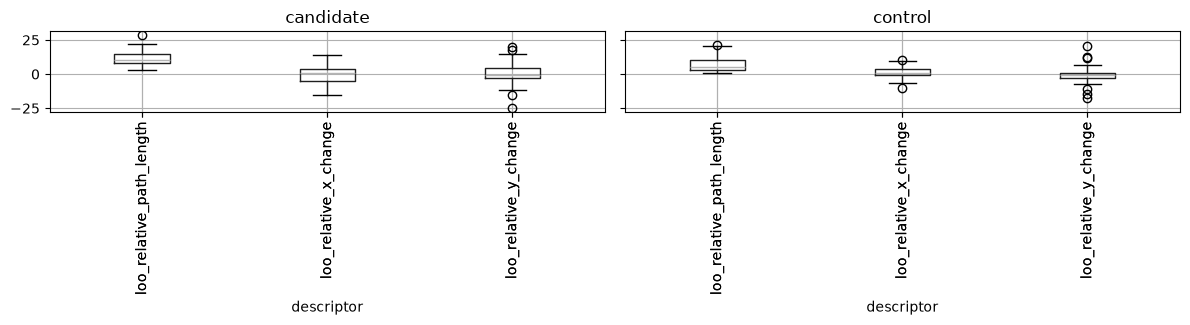

/var/folders/zk/r02nt9yn42130fswlkzl_whm0000gn/T/ipykernel_23997/227705307.py:11: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  g.boxplot(column=['candidate','control'],by='descriptor',ax=axs[0],rot=90);axs[0].set_title(f'{fam}: raw');axs[0].set_ylabel('native units')


/var/folders/zk/r02nt9yn42130fswlkzl_whm0000gn/T/ipykernel_23997/227705307.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.suptitle('');plt.tight_layout();plt.show()


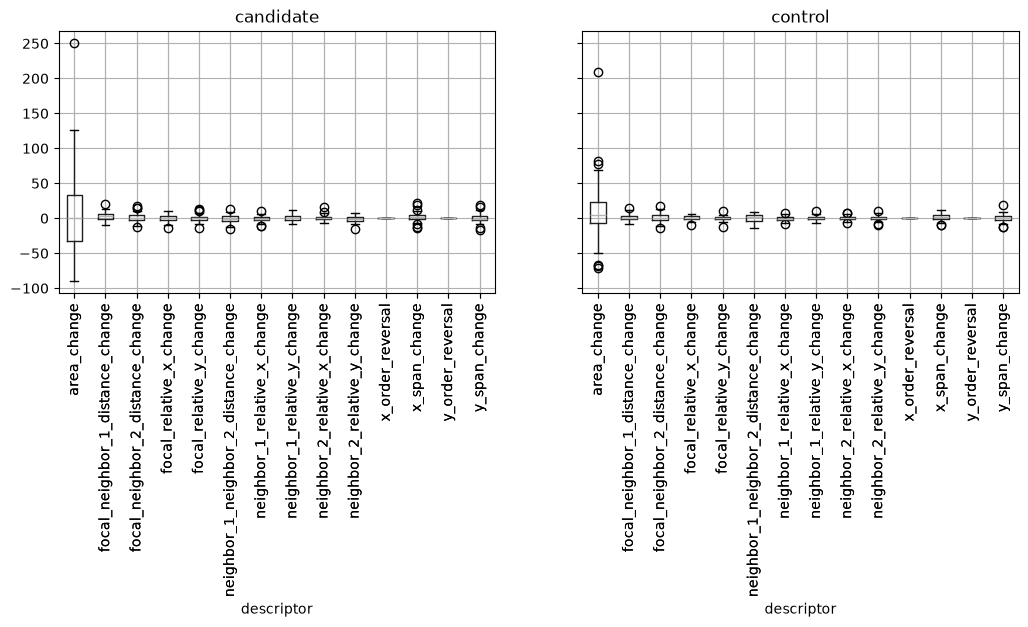

/var/folders/zk/r02nt9yn42130fswlkzl_whm0000gn/T/ipykernel_23997/227705307.py:11: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  g.boxplot(column=['candidate','control'],by='descriptor',ax=axs[0],rot=90);axs[0].set_title(f'{fam}: raw');axs[0].set_ylabel('native units')


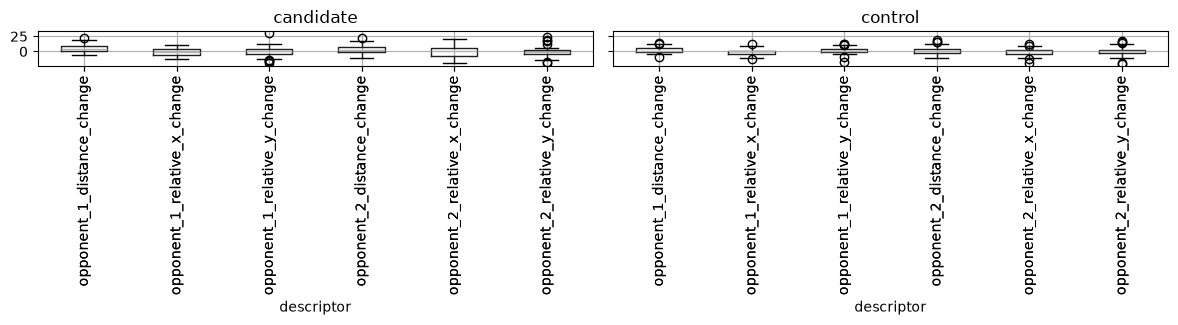

/var/folders/zk/r02nt9yn42130fswlkzl_whm0000gn/T/ipykernel_23997/227705307.py:11: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  g.boxplot(column=['candidate','control'],by='descriptor',ax=axs[0],rot=90);axs[0].set_title(f'{fam}: raw');axs[0].set_ylabel('native units')


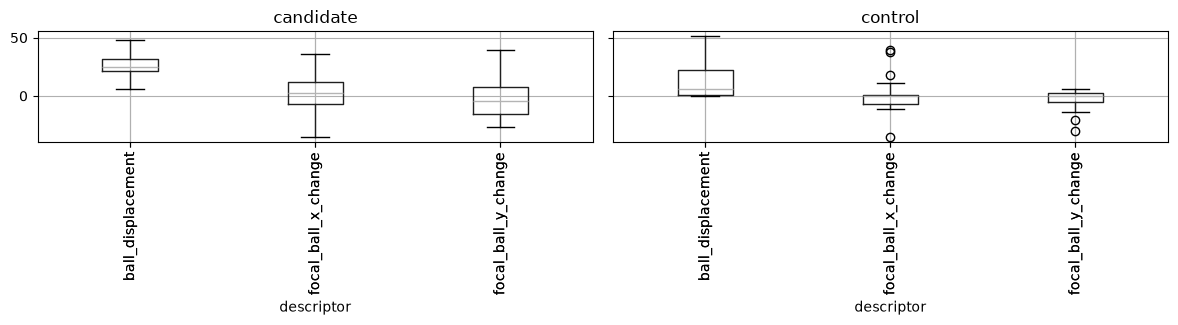

/var/folders/zk/r02nt9yn42130fswlkzl_whm0000gn/T/ipykernel_23997/227705307.py:11: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  g.boxplot(column=['candidate','control'],by='descriptor',ax=axs[0],rot=90);axs[0].set_title(f'{fam}: raw');axs[0].set_ylabel('native units')
/var/folders/zk/r02nt9yn42130fswlkzl_whm0000gn/T/ipykernel_23997/227705307.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.suptitle('');plt.tight_layout();plt.show()


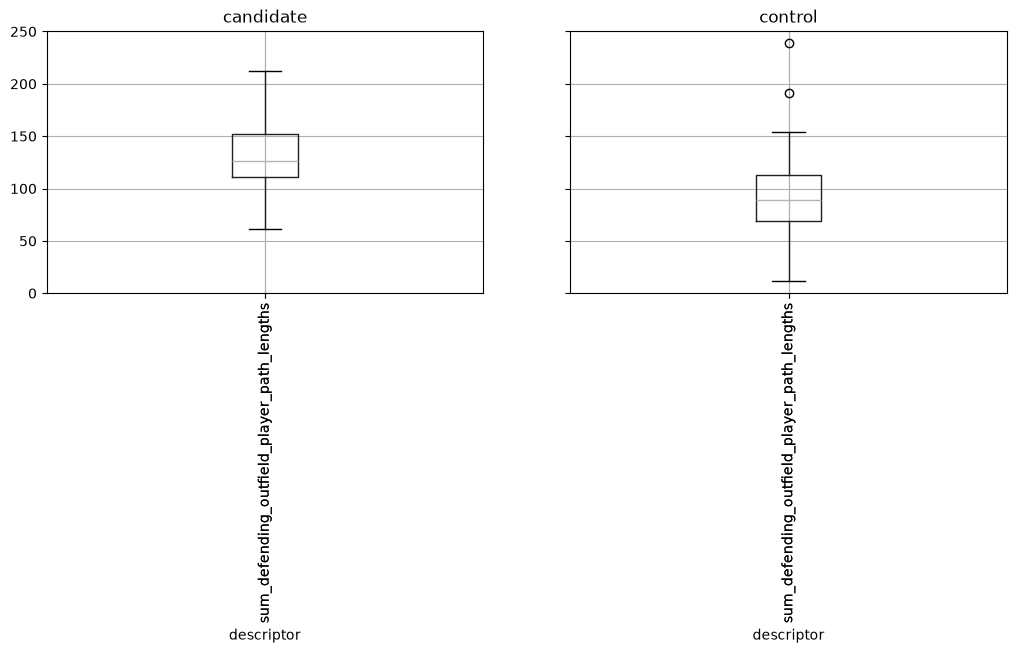

In [5]:
primary_raw,primary_summary=analyse(pairs,'primary_5s')
for fam in FAMILIES:
    print('FAMILY:',fam);display(primary_summary[primary_summary.family==fam].reset_index(drop=True))
fig,axes=plt.subplots(3,2,figsize=(15,13));
for ax,(fam,g) in zip(axes.flat,primary_summary.groupby('family',sort=False)):
    y=np.arange(len(g));ax.errorbar(g.median_difference,y,xerr=[g.median_difference-g.ci_low,g.ci_high-g.median_difference],fmt='o');ax.axvline(0,color='k',lw=.8);ax.set_yticks(y,g.descriptor);ax.set_title(fam);ax.set_xlabel('candidate − matched control (native units)')
plt.tight_layout();plt.show()
print('Raw paired distributions (not selected by result):')
for fam in FAMILIES:
    g=primary_raw[primary_raw.family==fam]; fig,axs=plt.subplots(1,2,figsize=(12,3.5));
    g.boxplot(column=['candidate','control'],by='descriptor',ax=axs[0],rot=90);axs[0].set_title(f'{fam}: raw');axs[0].set_ylabel('native units')
    for name,x in g.groupby('descriptor'): axs[1].hist(x.candidate-x.control,bins=12,alpha=.35,label=name)
    axs[1].axvline(0,color='k',lw=.8);axs[1].set_title('paired differences');axs[1].set_xlabel('candidate − control');
    plt.suptitle('');plt.tight_layout();plt.show()

In [6]:
def same_possession(period,t,poss,bounds):
    z=poss_events[(poss_events.Period==period)&poss_events['Start Time [s]'].between(t+bounds[0],t+bounds[1])]
    return possession_at(period,t+bounds[0])==poss and (z.empty or z.Team.eq(poss).all())
def build_negative_pool(cands,bounds):
    result={}
    for p,poss in sorted({(c['period'],c['possession']) for c in cands}):
        valid=[];ts=tracking.loc[tracking.Period==p,'Time [s]'];lo,hi=math.ceil(ts.min()-bounds[0]),math.floor(ts.max()-bounds[1])
        for s in range(lo,hi+1):
            if near_any(s,reception_times[p]) or near_any(s,restart_times[p]) or not same_possession(p,s,poss,bounds):continue
            r,why=anchor_record(p,float(s),poss,bounds,'shifted_negative')
            if r is not None:valid.append(r)
        result[(p,poss)]=valid
    return result
def shifted_negative(c,bounds,pools):
    p,t,poss=c['period'],c['time'],c['possession'];valid=[r for r in pools[(p,poss)] if abs(r['time']-t)>=3]
    if not valid:return None
    rng=np.random.default_rng(child_seed(f"negative:{p}:{t}:{bounds}"));return valid[int(rng.integers(len(valid)))]
negative_pool=build_negative_pool(candidates,BOUNDS)
neg_pairs=[(c,n) for c in candidates if (n:=shifted_negative(c,BOUNDS,negative_pool)) is not None]
neg_raw,neg_summary=analyse(neg_pairs,'shifted_negative_5s')
print({'negative_pairs':len(neg_pairs),'candidate_count':len(candidates),'support':len(neg_pairs)/len(candidates)})
display(neg_summary)

{'negative_pairs': 315, 'candidate_count': 315, 'support': 1.0}


,family,descriptor,n,candidate_median,control_median,median_difference,ci_low,ci_high,dz,p,test,p_holm
0,collective,centroid_x_displacement,315,-0.073185,-1.769880,0.519855,-0.708435,1.734390,0.012666,8.225118e-01,monte_carlo,0.822512
1,collective,centroid_y_displacement,315,-0.186592,0.274924,-0.683060,-1.544756,0.564604,-0.102522,7.051929e-02,monte_carlo,0.141039
2,collective,centroid_path_length,315,10.361211,5.005525,5.327344,4.461770,5.966899,0.776305,9.999900e-06,monte_carlo,0.000040
3,collective,directional_coherence,315,0.900518,0.766308,0.072411,0.040353,0.113603,0.332276,9.999900e-06,monte_carlo,0.000040
4,focal,loo_relative_x_change,315,0.709333,-0.269267,0.287583,-0.766500,1.342483,0.002089,9.710403e-01,monte_carlo,0.971040
5,focal,loo_relative_y_change,315,0.212916,0.088249,-0.427267,-1.695693,0.600893,-0.145242,1.067989e-02,monte_carlo,0.021360
6,focal,loo_relative_path_length,315,11.223445,3.651073,6.536550,5.851447,7.130592,1.043098,9.999900e-06,monte_carlo,0.000030
7,local_configuration,focal_neighbor_1_distance_change,315,1.874419,0.548461,0.661835,-0.319451,1.829261,0.083538,1.380586e-01,monte_carlo,0.690293
8,local_configuration,focal_neighbor_2_distance_change,315,-0.863173,2.180265,-2.215706,-3.285620,-1.386739,-0.313921,9.999900e-06,monte_carlo,0.000130
9,local_configuration,neighbor_1_neighbor_2_distance_change,315,0.166402,0.926629,-0.752540,-2.048426,-0.033078,-0.225571,8.999910e-05,monte_carlo,0.001080


In [7]:
# Independently reconstructed eight-second sensitivity.
B8=(-3,5);c8,a8,e8=reception_candidates(B8);p8,pa8=control_pool(c8,B8,e8);pairs8,u8=match_records(c8,p8,B8);raw8,sum8=analyse(pairs8,'eight_second')
negative_pool8=build_negative_pool(c8,B8);neg8=[(c,n) for c in c8 if (n:=shifted_negative(c,B8,negative_pool8)) is not None];negraw8,negsum8=analyse(neg8,'shifted_negative_8s')
print({'candidate_attrition':a8,'matched_pairs':len(pairs8),'support':len(pairs8)/len(c8) if c8 else 0,'negative_pairs':len(neg8)});display(sum8)

{'candidate_attrition': {'total_passes': 799, 'restart_proximity': 182, 'eligible_before_overlap': 617, 'overlap_suppressed': 373, 'retained': 244}, 'matched_pairs': 21, 'support': 0.0860655737704918, 'negative_pairs': 244}


,family,descriptor,n,candidate_median,control_median,median_difference,ci_low,ci_high,dz,p,test,p_holm
0,collective,centroid_x_displacement,21,0.831075,-7.988820,6.373710,-3.076185,10.169250,0.253524,0.259837,monte_carlo,0.779512
1,collective,centroid_y_displacement,21,0.479468,0.584936,0.122060,-3.249516,2.637992,-0.092714,0.677773,monte_carlo,0.779512
2,collective,centroid_path_length,21,16.319464,10.865381,5.662065,2.536400,10.346817,0.775201,0.002180,monte_carlo,0.008720
3,collective,directional_coherence,21,0.834430,0.897504,-0.092213,-0.144004,-0.003431,-0.223766,0.320127,monte_carlo,0.779512
4,focal,loo_relative_x_change,21,0.475883,0.589983,0.119350,-7.827167,6.822433,-0.039954,0.853461,monte_carlo,1.000000
5,focal,loo_relative_y_change,21,-0.207173,0.456204,-0.568556,-2.864160,2.419667,0.012614,0.957760,monte_carlo,1.000000
6,focal,loo_relative_path_length,21,16.048871,9.077344,8.190016,2.314282,11.235472,0.920151,0.000500,monte_carlo,0.001500
7,local_configuration,focal_neighbor_1_distance_change,21,5.602562,1.839832,0.976980,-1.826586,7.790415,0.079970,0.736383,monte_carlo,1.000000
8,local_configuration,focal_neighbor_2_distance_change,21,1.444899,0.807365,-3.263368,-7.057442,7.390841,0.068820,0.753342,monte_carlo,1.000000
9,local_configuration,neighbor_1_neighbor_2_distance_change,21,-1.307398,3.124670,-5.779965,-9.715513,2.654776,-0.440381,0.056229,monte_carlo,0.730983


In [8]:
# Pre-anchor movement matching sensitivity: same primary candidates/pool, extra frozen bins.
pre_pairs,pre_unmatched=match_records(candidates,pool,BOUNDS,extra=True);pre_raw,pre_summary=analyse(pre_pairs,'preanchor')
print({'matched_pairs':len(pre_pairs),'support':len(pre_pairs)/len(candidates) if candidates else 0,'unmatched':len(pre_unmatched)});display(pre_summary)

{'matched_pairs': 15, 'support': 0.047619047619047616, 'unmatched': 300}


,family,descriptor,n,candidate_median,control_median,median_difference,ci_low,ci_high,dz,p,test,p_holm
0,collective,centroid_x_displacement,15,-1.545705,-2.448075,-0.033810,-4.170285,4.323060,0.146895,0.585815,exact,1.000000
1,collective,centroid_y_displacement,15,-0.369444,0.773704,-3.374160,-9.321848,2.552108,-0.555944,0.049927,exact,0.199707
2,collective,centroid_path_length,15,11.161700,8.386145,-0.262970,-1.475117,2.789570,0.111448,0.670288,exact,1.000000
3,collective,directional_coherence,15,0.919900,0.920105,0.006105,-0.023440,0.131807,-0.013178,0.960938,exact,1.000000
4,focal,loo_relative_x_change,15,0.885617,-0.491400,-2.434483,-6.527695,2.466567,-0.265049,0.318176,exact,0.636353
5,focal,loo_relative_y_change,15,1.712089,-2.150840,3.783142,1.031182,7.940511,0.480021,0.085632,exact,0.256897
6,focal,loo_relative_path_length,15,9.834984,7.955396,0.554985,-4.407513,7.629776,0.085069,0.744141,exact,0.744141
7,local_configuration,focal_neighbor_1_distance_change,15,-0.499986,3.148246,-1.290112,-6.139309,0.361800,-0.185269,0.489746,exact,1.000000
8,local_configuration,focal_neighbor_2_distance_change,15,-1.540776,0.299932,-1.326732,-5.111268,2.841987,-0.344597,0.203979,exact,1.000000
9,local_configuration,neighbor_1_neighbor_2_distance_change,15,-1.113776,2.940170,-1.466061,-4.202664,2.960843,-0.213515,0.424744,exact,1.000000


In [9]:
# Possession-change sensitivity, reconstructed independently under v1.1.
pc,pc_attr,pc_eligible=possession_change_candidates(BOUNDS);pc_pool,pc_pool_attr=control_pool(pc,BOUNDS,eligible);pc_pairs,pc_unmatched=match_records(pc,pc_pool,BOUNDS);pc_raw,pc_summary=analyse(pc_pairs,'possession_change')
print({'candidate_attrition':pc_attr,'control_pool':len(pc_pool),'matched_pairs':len(pc_pairs),'support':len(pc_pairs)/len(pc) if pc else 0});display(pc_summary)

{'candidate_attrition': {'qualifying_possession_events': 1178, 'team_changes': 328, 'restart_proximity': 131, 'eligible_before_overlap': 197, 'overlap_suppressed': 61, 'retained': 136}, 'control_pool': 312, 'matched_pairs': 23, 'support': 0.16911764705882354}


,family,descriptor,n,candidate_median,control_median,median_difference,ci_low,ci_high,dz,p,test,p_holm
0,collective,centroid_x_displacement,23,-0.403305,-3.386880,1.549380,-0.168735,8.899695,0.468431,0.034490,monte_carlo,0.103469
1,collective,centroid_y_displacement,23,0.906440,-0.014144,0.517344,-1.829132,3.148672,0.122331,0.562484,monte_carlo,1.000000
2,collective,centroid_path_length,23,9.607876,3.816773,4.057803,1.403969,6.685690,0.957943,0.000050,monte_carlo,0.000200
3,collective,directional_coherence,23,0.723003,0.797322,-0.015014,-0.091724,0.077189,-0.097274,0.643534,monte_carlo,1.000000
4,focal,loo_relative_x_change,23,0.401917,0.332150,0.259467,-3.147550,4.172117,0.048025,0.818202,monte_carlo,0.818202
5,focal,loo_relative_y_change,23,0.370676,-1.056644,0.839876,-0.392133,3.600751,0.252024,0.237888,monte_carlo,0.475775
6,focal,loo_relative_path_length,23,9.943677,3.413092,5.431204,1.622586,8.539935,0.868201,0.000410,monte_carlo,0.001230
7,local_configuration,focal_neighbor_1_distance_change,23,1.348466,0.548547,0.709891,-1.577075,3.130704,-0.000760,0.997050,monte_carlo,1.000000
8,local_configuration,focal_neighbor_2_distance_change,23,-1.072939,1.032180,-1.341912,-5.143452,-0.416534,-0.210114,0.322807,monte_carlo,1.000000
9,local_configuration,neighbor_1_neighbor_2_distance_change,23,-0.709820,1.041730,-0.538386,-3.076597,5.556858,-0.024961,0.905651,monte_carlo,1.000000


## Adversarial interpretation and frozen decision

The frozen primary design retains 315 reception candidates but matches only 46 (14.6%), far below the pre-specified 70% support requirement. Rules are not loosened. In those 46 pairs, reception windows show longer collective-centroid paths (+3.92 m), longer focal leave-one-out-relative paths (+5.01 m), greater nearest-opponent distance change (+2.81 m), and much greater generic defending-player activity (+33.96 m). Local-configuration endpoint changes are otherwise broadly null. The ball family has only 20 complete pairs.

These differences do not isolate relational reconfiguration. The shifted-anchor comparison reproduces and often exceeds collective, focal, opponent-distance, ball, and generic-activity differences. The independently rebuilt eight-second analysis has only 21 matched pairs (8.6%); collective/focal paths and generic activity remain elevated, while local and most opponent-relational quantities remain null. Adding frozen pre-anchor movement bins leaves only 15 matches (4.8%) and removes the collective, focal, opponent, ball, and generic-activity contrasts. Possession-change anchors match only 23 of 136 retained candidates (16.9%) and again primarily show collective/focal paths, ball displacement, and generic activity rather than stable local or opponent-specific geometry.

Under the frozen A/B/C rule, the conclusion is **C**: current reception-anchored matched contrasts are poorly supported and the positive quantities are reproduced by generic activity and/or the negative control or vanish under pre-anchor matching. The analysis does not validate a universal relational-reconfiguration construct, tactical interpretation, responsibility, or causality. Prospectively specified typed channels remain useful diagnostics, but the Phase 2H requirement that change be inadequately described by a pre-specified baseline is not satisfied here.